In [27]:
# -----------------------------
# Netflix Dataset Analysis
# -----------------------------

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [28]:
# Read the uploaded dataset
df = pd.read_csv('Netflix Dataset.csv')


In [29]:
# Display basic info to confirm load
print("Dataset loaded successfully!")
print(f"Total Records: {df.shape[0]}, Total Columns: {df.shape[1]}\n")


Dataset loaded successfully!
Total Records: 7789, Total Columns: 11



In [36]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert release_date to datetime
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

# Drop duplicates
df = df.drop_duplicates()


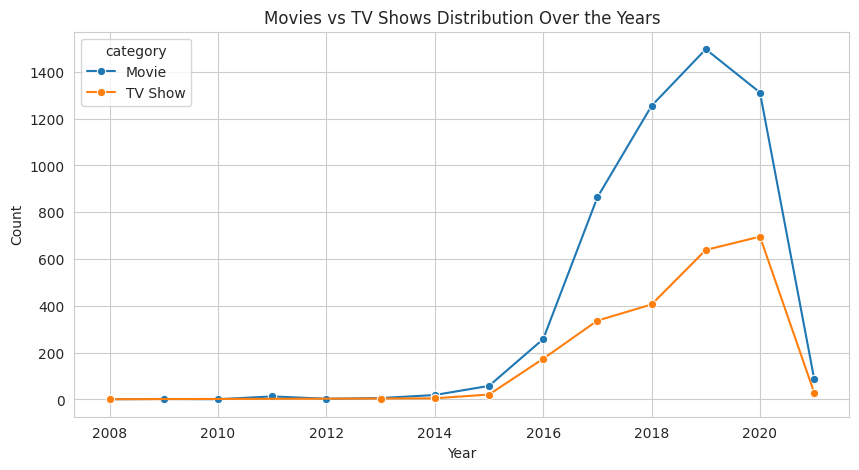

In [37]:
# -----------------------------
# 1️⃣ Distribution of Movies vs TV Shows Over the Years
# -----------------------------
if 'category' in df.columns and 'year' in df.columns:
    type_trend = df.groupby(['year', 'category']).size().reset_index(name='count')
    plt.figure(figsize=(10,5))
    sns.lineplot(data=type_trend, x='year', y='count', hue='category', marker='o')
    plt.title('Movies vs TV Shows Distribution Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()
else:
    print("⚠️ Columns 'category' or 'year' not found for distribution analysis.\n")


/tmp/ipython-input-3011482158.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


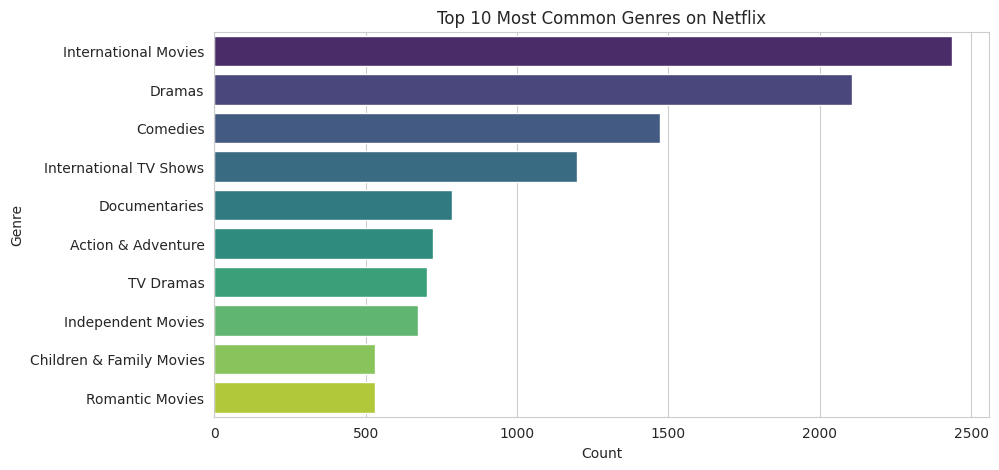

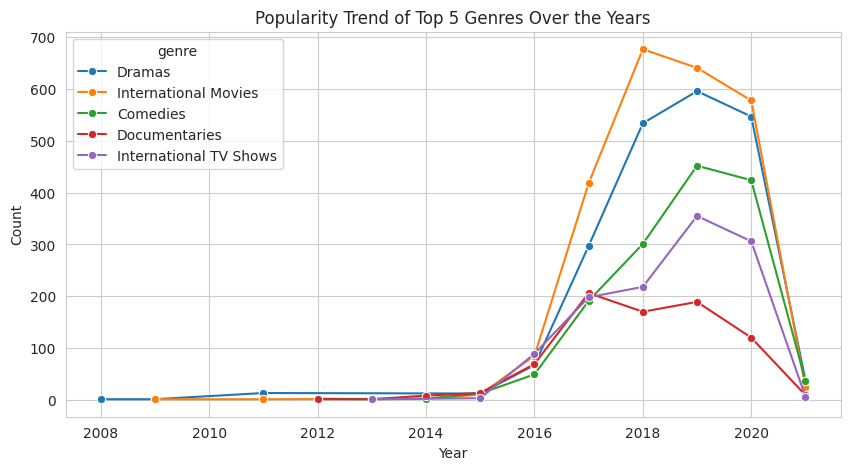

In [38]:
# -----------------------------
# 2️⃣ Most Common Genres (Type) and Their Popularity Over Time
# -----------------------------
if 'type' in df.columns:
    df['genre'] = df['type'].str.split(',')
    df_exploded = df.explode('genre')
    df_exploded['genre'] = df_exploded['genre'].str.strip()

    # Top 10 genres
    top_genres = df_exploded['genre'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
    plt.title('Top 10 Most Common Genres on Netflix')
    plt.xlabel('Count')
    plt.ylabel('Genre')
    plt.show()

    # Popularity trend for top 5 genres
    top5 = top_genres.index[:5]
    genre_trend = df_exploded[df_exploded['genre'].isin(top5)].groupby(['year','genre']).size().reset_index(name='count')
    plt.figure(figsize=(10,5))
    sns.lineplot(data=genre_trend, x='year', y='count', hue='genre', marker='o')
    plt.title('Popularity Trend of Top 5 Genres Over the Years')
    plt.xlabel('Year')
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()
else:
    print("⚠️ Column 'type' not found for genre analysis.\n")


/tmp/ipython-input-3948461972.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='coolwarm')


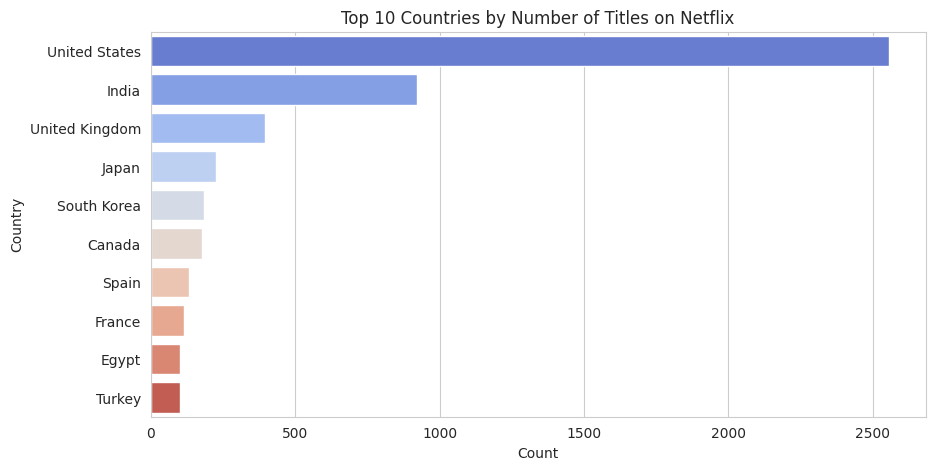

✅ Netflix Content Trends Summary:
- Distribution of Movies vs TV Shows over years visualized.
- Most popular genres and changing trends shown.
- Top 10 contributing countries displayed.


In [39]:
# -----------------------------
# 3️⃣ Country-wise Contributions
# -----------------------------
if 'country' in df.columns:
    country_counts = df['country'].value_counts().head(10)
    plt.figure(figsize=(10,5))
    sns.barplot(x=country_counts.values, y=country_counts.index, palette='coolwarm')
    plt.title('Top 10 Countries by Number of Titles on Netflix')
    plt.xlabel('Count')
    plt.ylabel('Country')
    plt.show()
else:
    print("⚠️ Column 'country' not found for country-wise analysis.\n")

# -----------------------------
# Summary Insights (Only as Required)
# -----------------------------
print("✅ Netflix Content Trends Summary:")
print("- Distribution of Movies vs TV Shows over years visualized.")
print("- Most popular genres and changing trends shown.")
print("- Top 10 contributing countries displayed.")